In [2]:
%cd ..

/home/nick/Documents/4tb_sync/UMD files/research projects/gradient_estimators_for_measles_vaccine/code/WD_LR_grad_est_for_SIR_model


In [3]:
from tsir_wd import *
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

In [8]:
total_samples = 1000

# try beta "prior" for v
# variance = O(1/conf)
v = 0.1
conf = 100
prior_alpha = conf*v
prior_beta = conf*(1-v)

sampled_v = scipy.stats.beta.rvs(a=prior_alpha, b=prior_beta, size=total_samples)

# try gamma "prior" for beta
# variance = prior_a / (prior_b)^2 = prior_a * (beta / prior_a)^2 = beta / prior_a = O(1/prior_a)
beta = 4
prior_a = 100
prior_b = beta/prior_a

sampled_beta = scipy.stats.gamma.rvs(a=prior_a,scale=prior_b, size=total_samples)

N = 1000
i0 = 1
T = 10
N_samples = 5

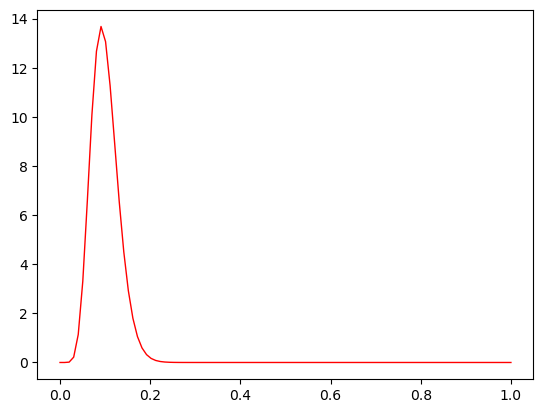

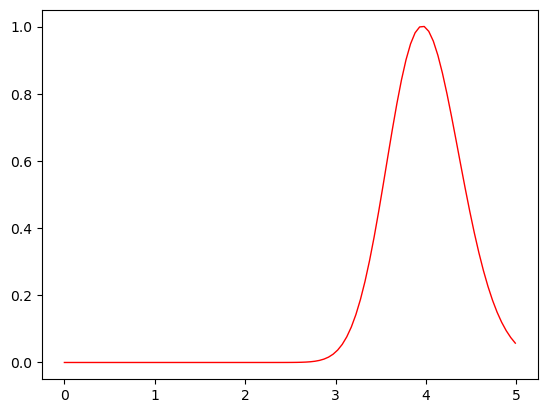

In [9]:
# plot distributions

from scipy.stats import beta
from scipy.stats import gamma

plt.figure()
x = np.linspace(0,
                1, 100)
plt.plot(x, beta.pdf(x, a=prior_alpha, b=prior_beta),
       'r-', lw=1, label='beta pdf')

plt.figure()
x = np.linspace(0,
                gamma.ppf(0.99, a=prior_a, scale=prior_b), 100)
plt.plot(x, gamma.pdf(x, a=prior_a, scale=prior_b),
       'r-', lw=1, label='gamma pdf')

In [10]:
import multiprocess as mp
def draw_samples_random_params(N, i0, 
                               v, beta, v_conf, beta_conf, 
                               T, 
                               N_samples, scrambler_seed, 
                               max_scrambler = 1e8, calc_LR = True,
                               v_seed=12345, beta_seed=51932, 
                               cores=1, random_params=True):
    """
    Sample several simulation paths of the tSIR model, under a Beta
    prior on v and a Gamma prior on beta.

    Parameters
    ----------
    N : int
        Total population size.
    v : float
        Immunization rate. Between 0 and 1.
        Represents the mean of the prior distribution on v.
    v_conf: float
        Confidence parameter for the prior distribution.
        Larger means less variance. Variance scales as O(1/v_var).
    i0 : int
        Number of initially infected individuals.
    beta : float
        Contact rate. Positive number.
        Represents the mean of the prior distribution on beta.
    beta_conf: float
        Confidence parameter for the prior distribution of beta.
        Larger means less variance. Variance scales as O(1/v_var).
    T : int
        Time horizon (number of iterations to run the sim for)
    N_samples : int
        Number of sample paths to draw.
    scrambler_seed : int
        Random seed to use for the 'scrambler' 
        (generates random seeds for each simulation path.)
    max_scrambler : int, optional
        Maximum seed value the scrambler can generate. The default is 1e8.
    calc_LR : bool, optional
        Whether to calculate the likelihood-ratios of the transition kernel
        with respect to the contact rate. The default is True.

    Returns
    -------
    orig_samples : np.array[int] of length N_samples
        The total infected along the unperturbed sample paths.
    plus_samples : np.array[int] of length N_samples
        The total infected along the sample paths using the \mu^+ 
        distribution for number initially immune.
    minus_samples : np.array[int] of length N_samples
        The total infected along the sample paths using the \mu^- 
        distribution for number initially immune.
    trajectories : np.array[int] of shape (T+1, N_samples)
        The number infected at each timestep, for each sample path.
        Rows are timestep indices and columns are sample indices.
    score_samples : np.array[int] of shape (T, N_samples)
        The score function of the transition kernel P(X_{j+1} | X_j)
        with respect to the contact rate beta, evaluated at the
        the sampled states.
    """
    orig_samples = np.empty(N_samples, dtype=int)
    plus_samples = np.empty(N_samples, dtype=int)
    minus_samples = np.empty(N_samples, dtype=int)

    scrambler = np.random.default_rng(seed=scrambler_seed)

    prior_alpha = v_conf*v
    prior_beta = v_conf*(1-v)
    prior_a = beta_conf
    prior_b = beta/prior_a

    if random_params:
        sampled_v = scipy.stats.beta.rvs(a=prior_alpha, b=prior_beta, size=N_samples, random_state=v_seed)
        sampled_beta = scipy.stats.gamma.rvs(a=prior_a, scale=prior_b, size=N_samples, random_state=beta_seed)
    else:
        sampled_v = np.ones(N_samples)*v
        sampled_beta = np.ones(N_samples)*beta
    
    if calc_LR:
        trajectories = np.empty((T+1, N_samples), dtype=int)
        score_samples = np.empty((T, N_samples), dtype=float)
    else:
        trajectories = None
        score_samples = None

    def inner_loop(i, s1, s2, n_val, i0_val, t_val, calc_lr_val, v_val, beta_val, s_v, s_beta):
        orig, plus, minus = tSIR_WD_CRN(
            N=n_val, v=s_v, i0=i0_val, beta=s_beta, T=t_val, pop_seed=s1, dyn_seed=s2
        )
        res_orig = np.sum(orig, axis=0)[1]
        res_plus = np.sum(plus, axis=0)[1]
        res_minus = np.sum(minus, axis=0)[1]

        traj = None
        scores = None
        
        if calc_lr_val:
            traj = orig[:, 1]
            # Calculate scores as a list or numpy array
            scores = [LR_beta_term(orig[t+1], orig[t], s_beta, n_val) for t in range(t_val)]
            
        return res_orig, res_plus, res_minus, traj, scores
        
    if cores > 1:
        # 1. Prepare seeds
        seeds1 = scrambler.integers(0, max_scrambler, size=N_samples)
        seeds2 = scrambler.integers(0, max_scrambler, size=N_samples)
        
        # 2. Package all arguments into a list of tuples for starmap
        # Note: We pass everything the function needs to avoid global scope issues
        tasks = [
            (i, seeds1[i], seeds2[i], N, i0, T, calc_LR, v, beta, sampled_v[i], sampled_beta[i]) 
            for i in range(N_samples)
        ]

        with mp.Pool(cores) as pool:
            results = pool.starmap(inner_loop, tasks)

        # 3. Unpack results into your pre-allocated arrays
        for i, res in enumerate(results):
            orig_samples[i], plus_samples[i], minus_samples[i], traj, scores = res
            
            if calc_LR:
                trajectories[:, i] = traj
                score_samples[:, i] = scores
    else:
        for i in range(N_samples):
            seed1 = scrambler.integers(0, max_scrambler)
            seed2 = scrambler.integers(0, max_scrambler)
            this_beta = sampled_beta[i]
            this_v = sampled_v[i]
            orig, plus, minus = tSIR_WD_CRN(
                N=N, v=this_v, i0=i0, beta=this_beta, T=T, pop_seed=seed1, dyn_seed=seed2
            )
            
            orig_samples[i] = np.sum(orig, axis=0)[1]
            plus_samples[i] = np.sum(plus, axis=0)[1]
            minus_samples[i] = np.sum(minus, axis=0)[1]
    
            if calc_LR:
                trajectories[:,i] = orig[:,1]
                
                for t in range(T):
                    step_score = LR_beta_term(orig[t+1], orig[t], beta, N)
                    score_samples[t, i] = step_score
        
    return orig_samples, plus_samples, minus_samples, trajectories, score_samples

In [13]:
N = 1000
i0 = 1
T = 10
N_samples = 20000
v = 0.1
beta = 4
v_conf = 10
beta_conf = 10
scrambler_seed= 551505

orig_samples, plus_samples, minus_samples, trajectories, score_samples = \
    draw_samples_random_params(N, i0, 
                               v, beta, v_conf, beta_conf, 
                               T, 
                               N_samples, scrambler_seed, 
                               max_scrambler = 1e8, calc_LR = True,
                               v_seed=12345, beta_seed=51932, 
                               cores=12, random_params=True)

In [15]:
beta_grad, beta_grad_sd = grad_wrt_beta(trajectories, score_samples, T, N_samples)
v_grad, v_grad_sd = grad_wrt_v(plus_samples, minus_samples, N, i0)
print(beta_grad, beta_grad_sd/np.sqrt(N_samples))
print(v_grad, v_grad_sd/np.sqrt(N_samples))

110.79954598221285 9.091002711748896
-1108.44045 115.17671574745566


In [70]:
import pandas as pd
old_run = pd.read_csv('output/big_run_combined.csv')

In [82]:
for idx, row in old_run[['v','beta']].iterrows():
    print(row['v'])
    print(row['beta'])

0.01
2.0
0.01
2.1
0.01
2.2
0.01
2.3
0.01
2.4
0.01
2.5
0.01
2.6
0.01
2.7
0.01
2.8
0.01
2.9
0.01
3.0
0.01
3.1
0.01
3.2
0.01
3.3
0.01
3.4000000000000004
0.01
3.5
0.01
3.6
0.01
3.7
0.01
3.8
0.01
3.9
0.01
4.0
0.05
2.0
0.05
2.1
0.05
2.2
0.05
2.3
0.05
2.4
0.05
2.5
0.05
2.6
0.05
2.7
0.05
2.8
0.05
2.9
0.05
3.0
0.05
3.1
0.05
3.2
0.05
3.3
0.05
3.4000000000000004
0.05
3.5
0.05
3.6
0.05
3.7
0.05
3.8
0.05
3.9
0.05
4.0
0.1
2.0
0.1
2.1
0.1
2.2
0.1
2.3
0.1
2.4
0.1
2.5
0.1
2.6
0.1
2.7
0.1
2.8
0.1
2.9
0.1
3.0
0.1
3.1
0.1
3.2
0.1
3.3
0.1
3.4000000000000004
0.1
3.5
0.1
3.6
0.1
3.7
0.1
3.8
0.1
3.9
0.1
4.0
0.15
2.0
0.15
2.1
0.15
2.2
0.15
2.3
0.15
2.4
0.15
2.5
0.15
2.6
0.15
2.7
0.15
2.8
0.15
2.9
0.15
3.0
0.15
3.1
0.15
3.2
0.15
3.3
0.15
3.4000000000000004
0.15
3.5
0.15
3.6
0.15
3.7
0.15
3.8
0.15
3.9
0.15
4.0
0.2
2.0
0.2
2.1
0.2
2.2
0.2
2.3
0.2
2.4
0.2
2.5
0.2
2.6
0.2
2.7
0.2
2.8
0.2
2.9
0.2
3.0
0.2
3.1
0.2
3.2
0.2
3.3
0.2
3.4000000000000004
0.2
3.5
0.2
3.6
0.2
3.7
0.2
3.8
0.2
3.9
0.2
4.0
0.25
2.0
0.25
2.1
0.25